# MIMIC-IV Demo — RMAB Transition Matrix Pipeline

This notebook processes the **MIMIC-IV Clinical Database Demo (v2.2)** to produce two empirical transition matrices for a **Restless Multi-Armed Bandit (RMAB)** model of ICU patient allocation.

Each patient is modelled as one RMAB *arm*. On each calendar day the arm occupies a discrete health *state*. The hospital can allocate ICU care to at most **K** patients simultaneously. Two Markov transition matrices are learned:
- **P_icu** — dynamics for a patient *inside* the ICU
- **P_nonicu** — dynamics for a patient *outside* the ICU

The pipeline runs end-to-end: raw gzipped CSVs → daily observations → discretised states → empirical transition counts → row-normalised probability matrices.

**Dataset:** 100 patients, MIMIC-IV Demo v2.2

---
## Section 1 — Setup & Data Loading

We import the standard scientific Python stack and load every relevant table from the compressed CSV files. Shape printouts confirm we loaded the expected row counts.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

# ── Base path ────────────────────────────────────────────────────────────────
BASE_PATH = os.path.join(
    r'C:\Users\eric\Desktop\Mimic RMAB',
    'data', 'mimic-iv-demo',
    'mimic-iv-clinical-database-demo-2.2'
)
HOSP = os.path.join(BASE_PATH, 'hosp')
ICU  = os.path.join(BASE_PATH, 'icu')

print('Base path:', BASE_PATH)
print('Exists:   ', os.path.isdir(BASE_PATH))

Base path: C:\Users\eric\Desktop\Mimic RMAB\data\mimic-iv-demo\mimic-iv-clinical-database-demo-2.2
Exists:    True


In [2]:
# ── Load hospital-level tables ───────────────────────────────────────────────
patients    = pd.read_csv(os.path.join(HOSP, 'patients.csv.gz'),
                          compression='gzip')
admissions  = pd.read_csv(os.path.join(HOSP, 'admissions.csv.gz'),
                          compression='gzip',
                          parse_dates=['admittime', 'dischtime', 'deathtime',
                                       'edregtime', 'edouttime'],
                          low_memory=False)
transfers   = pd.read_csv(os.path.join(HOSP, 'transfers.csv.gz'),
                          compression='gzip',
                          parse_dates=['intime', 'outtime'])
labevents   = pd.read_csv(os.path.join(HOSP, 'labevents.csv.gz'),
                          compression='gzip',
                          usecols=['subject_id', 'hadm_id', 'itemid',
                                   'charttime', 'valuenum'],
                          parse_dates=['charttime'],
                          low_memory=False)

# ── Load ICU-level tables ────────────────────────────────────────────────────
icustays    = pd.read_csv(os.path.join(ICU, 'icustays.csv.gz'),
                          compression='gzip',
                          parse_dates=['intime', 'outtime'])
chartevents = pd.read_csv(os.path.join(ICU, 'chartevents.csv.gz'),
                          compression='gzip',
                          usecols=['subject_id', 'hadm_id', 'stay_id',
                                   'charttime', 'itemid', 'valuenum'],
                          parse_dates=['charttime'],
                          low_memory=False)

# ── Print shapes ────────────────────────────────────────────────────────────
for name, df in [('patients',    patients),
                 ('admissions',  admissions),
                 ('transfers',   transfers),
                 ('labevents',   labevents),
                 ('icustays',    icustays),
                 ('chartevents', chartevents)]:
    print(f'{name:<14} shape: {df.shape}')

patients       shape: (100, 6)
admissions     shape: (275, 16)
transfers      shape: (1190, 7)
labevents      shape: (107727, 5)
icustays       shape: (140, 8)
chartevents    shape: (668862, 6)


---
## Section 2 — ICU / Non-ICU Day Labeling

For each hospital admission we enumerate **every calendar day** from `admittime` to `dischtime` (inclusive). We then cross-reference each day with the `icustays` table: a day is labelled `is_icu = 1` if any part of an ICU stay overlaps that calendar date for the same patient.

The result is a long-format DataFrame with one row per `(subject_id, hadm_id, date)` and an `is_icu` flag.

In [3]:
# Keep only admissions with valid admit/discharge timestamps
adm = admissions[['subject_id', 'hadm_id', 'admittime', 'dischtime',
                   'hospital_expire_flag']].dropna(subset=['admittime', 'dischtime']).copy()

# Normalise to date (midnight)
adm['admit_date']  = adm['admittime'].dt.normalize()
adm['disch_date']  = adm['dischtime'].dt.normalize()

# ── Expand each admission into daily rows ────────────────────────────────────
rows = []
for _, row in adm.iterrows():
    dates = pd.date_range(row['admit_date'], row['disch_date'], freq='D')
    for d in dates:
        rows.append({
            'subject_id':           row['subject_id'],
            'hadm_id':              row['hadm_id'],
            'date':                 d,
            'hospital_expire_flag': row['hospital_expire_flag'],
        })

daily = pd.DataFrame(rows)
print(f'Expanded daily rows: {len(daily):,}')
print(f'Unique admissions:   {daily["hadm_id"].nunique()}')

Expanded daily rows: 2,149
Unique admissions:   275


In [4]:
# ── Build ICU coverage set: (subject_id, date) that overlap an ICU stay ──────
# A calendar day D overlaps ICU stay [intime, outtime] if
# D <= outtime.date AND D >= intime.date

icu_rows = []
for _, stay in icustays.iterrows():
    icu_dates = pd.date_range(
        stay['intime'].normalize(),
        stay['outtime'].normalize(),
        freq='D'
    )
    for d in icu_dates:
        icu_rows.append({
            'subject_id': stay['subject_id'],
            'hadm_id':    stay['hadm_id'],
            'date':       d,
        })

icu_days = pd.DataFrame(icu_rows).drop_duplicates(
    subset=['subject_id', 'hadm_id', 'date']
)
icu_days['is_icu'] = 1
print(f'ICU day records (unique): {len(icu_days):,}')

ICU day records (unique): 629


In [5]:
# Merge is_icu flag onto daily
daily = daily.merge(icu_days[['subject_id', 'hadm_id', 'date', 'is_icu']],
                    on=['subject_id', 'hadm_id', 'date'],
                    how='left')
daily['is_icu'] = daily['is_icu'].fillna(0).astype(int)

print('is_icu distribution:')
print(daily['is_icu'].value_counts())
print('\nSample:')
daily.head(8)

is_icu distribution:
is_icu
0    1523
1     626
Name: count, dtype: int64

Sample:


,subject_id,hadm_id,date,hospital_expire_flag,is_icu
0,10004235,24181354,2196-02-24,0,1
1,10004235,24181354,2196-02-25,0,1
2,10004235,24181354,2196-02-26,0,1
3,10004235,24181354,2196-02-27,0,1
4,10004235,24181354,2196-02-28,0,1
5,10004235,24181354,2196-02-29,0,1
6,10004235,24181354,2196-03-01,0,0
7,10004235,24181354,2196-03-02,0,0


---
## Section 3 — Vital Signs Extraction

We pull four key vitals from `chartevents`:
- **Heart Rate** (itemid 220045)
- **Mean Arterial Pressure — MAP** (itemid 220181)
- **SpO2 / Pulse Oximetry** (itemid 220277)
- **Respiratory Rate** (itemid 220210)

**GCS** is computed as the sum of three sub-components (Eye 220739 + Verbal 223900 + Motor 223901), first grouped by `stay_id + charttime` to align simultaneous readings, then summed.

All vitals are then aggregated to a **daily mean** per patient.

In [6]:
# Item IDs
VITAL_ITEMS = {
    220045: 'heart_rate',
    220181: 'map',
    220210: 'resp_rate',
    220277: 'spo2',
}
GCS_ITEMS = [220739, 223900, 223901]   # Eye, Verbal, Motor

# Filter chartevents to relevant items only
ce_vitals = chartevents[
    chartevents['itemid'].isin(list(VITAL_ITEMS.keys()) + GCS_ITEMS)
].copy()

ce_vitals['date'] = ce_vitals['charttime'].dt.normalize()

print(f'Chartevents rows for selected items: {len(ce_vitals):,}')
print(ce_vitals['itemid'].value_counts())

Chartevents rows for selected items: 59,499
itemid
220210    13913
220045    13913
220277    13540
220181     8342
220739     3274
223900     3266
223901     3251
Name: count, dtype: int64


In [ ]:
# ── Non-GCS vitals: daily mean per patient ───────────────────────────────────
ce_nonGCS = ce_vitals[ce_vitals['itemid'].isin(VITAL_ITEMS.keys())].copy()
ce_nonGCS['vital'] = ce_nonGCS['itemid'].map(VITAL_ITEMS)

vitals_daily = (
    ce_nonGCS
    .groupby(['subject_id', 'date', 'vital'])['valuenum']
    .mean()
    .reset_index()
    .pivot_table(index=['subject_id', 'date'], columns='vital',
                 values='valuenum', aggfunc='mean')
    .reset_index()
)
vitals_daily.columns.name = None

print('vitals_daily shape:', vitals_daily.shape)
vitals_daily.head(5)

vitals_daily shape: (625, 6)


,subject_id,date,heart_rate,map,resp_rate,spo2
0,10000032,2180-07-23,96.500000,62.300000,20.700000,96.300000
1,10001217,2157-11-20,96.000000,96.600000,22.800000,97.600000
2,10001217,2157-11-21,92.681818,92.761905,20.909091,95.727273
3,10001217,2157-12-19,81.300000,93.000000,14.800000,94.600000
4,10001217,2157-12-20,78.466667,76.928571,17.866667,93.400000


In [8]:
# ── GCS: sum sub-components per charttime, then daily mean ───────────────────
ce_gcs = ce_vitals[ce_vitals['itemid'].isin(GCS_ITEMS)].copy()

# Sum the three sub-scores at each charting moment (same stay_id + charttime)
gcs_moment = (
    ce_gcs
    .groupby(['subject_id', 'stay_id', 'charttime'])['valuenum']
    .sum()
    .reset_index()
    .rename(columns={'valuenum': 'gcs_total'})
)

# Only keep moments where all three components were charted (sum should be >= 3)
# GCS minimum is 3 (1+1+1), maximum is 15 (4+5+6)
gcs_moment = gcs_moment[(gcs_moment['gcs_total'] >= 3) &
                         (gcs_moment['gcs_total'] <= 15)]

gcs_moment['date'] = gcs_moment['charttime'].dt.normalize()

gcs_daily = (
    gcs_moment
    .groupby(['subject_id', 'date'])['gcs_total']
    .mean()
    .reset_index()
)

print('gcs_daily shape:', gcs_daily.shape)
gcs_daily.head(5)

gcs_daily shape: (615, 3)


,subject_id,date,gcs_total
0,10000032,2180-07-23,14.666667
1,10001217,2157-11-20,15.000000
2,10001217,2157-11-21,15.000000
3,10001217,2157-12-19,15.000000
4,10001217,2157-12-20,15.000000


In [9]:
# Merge GCS into vitals_daily
vitals_daily = vitals_daily.merge(gcs_daily, on=['subject_id', 'date'], how='outer')
print('vitals_daily shape after GCS merge:', vitals_daily.shape)
vitals_daily.head(5)

vitals_daily shape after GCS merge: (625, 7)


,subject_id,date,heart_rate,map,resp_rate,spo2,gcs_total
0,10000032,2180-07-23,96.500000,62.300000,20.700000,96.300000,14.666667
1,10001217,2157-11-20,96.000000,96.600000,22.800000,97.600000,15.000000
2,10001217,2157-11-21,92.681818,92.761905,20.909091,95.727273,15.000000
3,10001217,2157-12-19,81.300000,93.000000,14.800000,94.600000,15.000000
4,10001217,2157-12-20,78.466667,76.928571,17.866667,93.400000,15.000000


---
## Section 4 — Lab Values Extraction

From `labevents` we extract:
- **Lactate** (itemid 50813) — marker of tissue hypoperfusion / shock
- **Creatinine** (itemid 50912) — marker of renal function

Labs are **not drawn every day**, so after computing daily means we **forward-fill** values within each patient, carrying the most recent measurement forward until a new one is available. This is standard clinical practice when interpreting lab trends.

In [10]:
LAB_ITEMS = {
    50813: 'lactate',
    50912: 'creatinine',
}

# Filter labevents
le = labevents[labevents['itemid'].isin(LAB_ITEMS.keys())].copy()
le['lab']  = le['itemid'].map(LAB_ITEMS)
le['date'] = le['charttime'].dt.normalize()

print(f'Lab rows selected: {len(le):,}')
print(le['lab'].value_counts())

Lab rows selected: 3,761
lab
creatinine    3003
lactate        758
Name: count, dtype: int64


In [11]:
# Daily mean per patient per lab
labs_daily_raw = (
    le
    .groupby(['subject_id', 'date', 'lab'])['valuenum']
    .mean()
    .reset_index()
    .pivot_table(index=['subject_id', 'date'], columns='lab',
                 values='valuenum', aggfunc='mean')
    .reset_index()
)
labs_daily_raw.columns.name = None

print('labs_daily_raw shape:', labs_daily_raw.shape)
labs_daily_raw.head(5)

labs_daily_raw shape: (2331, 4)


,subject_id,date,creatinine,lactate
0,10000032,2180-03-23,0.4,NaN
1,10000032,2180-05-06,0.3,NaN
2,10000032,2180-05-07,0.3,NaN
3,10000032,2180-06-03,0.4,NaN
4,10000032,2180-06-22,0.3,NaN


In [12]:
# ── Forward-fill lab values within each patient ──────────────────────────────
# First, join onto the full daily grid so every admission-day has a row,
# then forward-fill within subject_id.

# Build the per-patient date grid from the daily ICU-label table
patient_dates = daily[['subject_id', 'date']].drop_duplicates().copy()

labs_daily = patient_dates.merge(labs_daily_raw,
                                  on=['subject_id', 'date'],
                                  how='left')

# Sort then forward-fill within each patient
labs_daily = labs_daily.sort_values(['subject_id', 'date'])
labs_daily[['lactate', 'creatinine']] = (
    labs_daily
    .groupby('subject_id')[['lactate', 'creatinine']]
    .ffill()
)

print('labs_daily shape (after ffill):', labs_daily.shape)
print('\nMissingness after forward-fill:')
print(labs_daily[['lactate', 'creatinine']].isna().mean().round(3))
labs_daily.head(8)

labs_daily shape (after ffill): (2146, 4)

Missingness after forward-fill:
lactate       0.184
creatinine    0.008
dtype: float64


,subject_id,date,creatinine,lactate
196,10000032,2180-05-06,0.3,NaN
197,10000032,2180-05-07,0.3,NaN
1004,10000032,2180-06-26,0.6,1.7
1005,10000032,2180-06-27,0.3,1.7
1009,10000032,2180-07-23,0.6,1.6
1010,10000032,2180-07-24,0.4,1.6
1011,10000032,2180-07-25,0.4,1.6
1006,10000032,2180-08-05,0.6,2.1


---
## Section 5 — Merge & Feature Assembly

We combine the three sources — daily ICU labels, daily vitals, and daily labs — into a single feature DataFrame, joining on `(subject_id, date)`.

Missing values are handled in two passes:
1. **Forward-fill** within each patient (carry the last known value forward)
2. **Median imputation** for any remaining NaNs (patients who never had the measurement recorded)

We print a missingness summary before and after imputation.

In [13]:
# Merge: start from the daily ICU-label table as the backbone
features = daily[['subject_id', 'hadm_id', 'date', 'is_icu',
                   'hospital_expire_flag']].copy()

features = features.merge(vitals_daily, on=['subject_id', 'date'], how='left')
features = features.merge(labs_daily,   on=['subject_id', 'date'], how='left')

feature_cols = ['map', 'spo2', 'gcs_total', 'lactate',
                'heart_rate', 'resp_rate', 'creatinine']

print('Merged features shape:', features.shape)
print('\n── Missingness (fraction NaN) BEFORE imputation ──')
print(features[feature_cols].isna().mean().round(3))

Merged features shape: (2149, 12)

── Missingness (fraction NaN) BEFORE imputation ──
map           0.769
spo2          0.711
gcs_total     0.714
lactate       0.184
heart_rate    0.710
resp_rate     0.709
creatinine    0.008
dtype: float64


In [14]:
# ── Pass 1: forward-fill within each patient ─────────────────────────────────
features = features.sort_values(['subject_id', 'date'])
features[feature_cols] = (
    features
    .groupby('subject_id')[feature_cols]
    .ffill()
)

print('── Missingness AFTER forward-fill ──')
print(features[feature_cols].isna().mean().round(3))

── Missingness AFTER forward-fill ──
map           0.248
spo2          0.234
gcs_total     0.235
lactate       0.184
heart_rate    0.233
resp_rate     0.233
creatinine    0.008
dtype: float64


In [15]:
# ── Pass 2: median imputation for remaining NaNs ─────────────────────────────
medians = features[feature_cols].median()
print('Medians used for imputation:')
print(medians.round(2))

features[feature_cols] = features[feature_cols].fillna(medians)

print('\n── Missingness AFTER median imputation ──')
print(features[feature_cols].isna().mean().round(3))
print('\nFeatures shape:', features.shape)
features.head(5)

Medians used for imputation:


map           76.14
spo2          96.62
gcs_total     15.00
lactate        1.50
heart_rate    89.50
resp_rate     19.86
creatinine     0.90
dtype: float64

── Missingness AFTER median imputation ──
map           0.0
spo2          0.0
gcs_total     0.0
lactate       0.0
heart_rate    0.0
resp_rate     0.0
creatinine    0.0
dtype: float64

Features shape: (2149, 12)


,subject_id,hadm_id,date,is_icu,hospital_expire_flag,heart_rate,map,resp_rate,spo2,gcs_total,creatinine,lactate
196,10000032,22595853,2180-05-06,0,0,89.5,76.136364,19.856667,96.625,15.000000,0.3,1.5
197,10000032,22595853,2180-05-07,0,0,89.5,76.136364,19.856667,96.625,15.000000,0.3,1.5
1004,10000032,22841357,2180-06-26,0,0,89.5,76.136364,19.856667,96.625,15.000000,0.6,1.7
1005,10000032,22841357,2180-06-27,0,0,89.5,76.136364,19.856667,96.625,15.000000,0.3,1.7
1009,10000032,29079034,2180-07-23,1,0,96.5,62.300000,20.700000,96.300,14.666667,0.6,1.6


---
## Section 6 — State Discretization

We map each patient-day into a single discrete health state using clinically motivated thresholds:

| Feature | Bins | Labels (0=worst → 2=best) |
|---|---|---|
| MAP (mmHg) | <65 / 65–100 / >100 | shock / normal / hypertensive |
| SpO2 (%) | <90 / 90–95 / ≥95 | critical / low / normal |
| GCS (total) | 3–8 / 9–12 / 13–15 | severe / moderate / normal |
| Lactate (mmol/L) | ≥4 / 2–4 / <2 | shock / elevated / normal |

The four 3-level bins are combined into a **base-3 composite index**:
$$\text{state} = \text{MAP\_bin} \times 27 + \text{SpO2\_bin} \times 9 + \text{GCS\_bin} \times 3 + \text{Lactate\_bin}$$

This gives $3^4 = 81$ live states (0–80) plus one **death state** (state = 81), for a total of **82 states**.

In [16]:
# ── Bin each variable ────────────────────────────────────────────────────────

# MAP: <65 → 0,  65-100 → 1,  >100 → 2
features['map_bin'] = pd.cut(
    features['map'],
    bins=[-np.inf, 65, 100, np.inf],
    labels=[0, 1, 2]
).astype(int)

# SpO2: <90 → 0,  90-95 → 1,  >=95 → 2
features['spo2_bin'] = pd.cut(
    features['spo2'],
    bins=[-np.inf, 90, 95, np.inf],
    labels=[0, 1, 2]
).astype(int)

# GCS: 3-8 → 0,  9-12 → 1,  13-15 → 2
features['gcs_bin'] = pd.cut(
    features['gcs_total'],
    bins=[2, 8, 12, 15],          # left-exclusive; 3-8 inclusive uses left=2
    labels=[0, 1, 2]
).astype(int)

# Lactate: >=4 → 0,  2-4 → 1,  <2 → 2
# Invert the ordering (higher lactate = worse)
features['lactate_bin'] = pd.cut(
    features['lactate'],
    bins=[-np.inf, 2, 4, np.inf],
    labels=[2, 1, 0]              # reversed: <2 best (2), >=4 worst (0)
).astype(int)

print('Bin distributions:')
for col in ['map_bin', 'spo2_bin', 'gcs_bin', 'lactate_bin']:
    print(f'  {col}: {features[col].value_counts().sort_index().to_dict()}')

Bin distributions:
  map_bin: {0: 200, 1: 1905, 2: 44}
  spo2_bin: {0: 3, 1: 390, 2: 1756}
  gcs_bin: {0: 93, 1: 181, 2: 1875}
  lactate_bin: {0: 58, 1: 397, 2: 1694}


In [17]:
# ── Composite state index (base-3) ───────────────────────────────────────────
features['state'] = (
    features['map_bin']     * 27 +
    features['spo2_bin']    *  9 +
    features['gcs_bin']     *  3 +
    features['lactate_bin']
)

N_STATES = 82   # 81 live states (0-80) + 1 death state (81)
DEATH_STATE = 81

# ── Mark death state ─────────────────────────────────────────────────────────
# Use hospital_expire_flag; overwrite state on the last day of a fatal admission
# Find the last day of each admission
last_day = (
    features
    .groupby('hadm_id')['date']
    .transform('max')
)
died_mask = (
    (features['hospital_expire_flag'] == 1) &
    (features['date'] == last_day)
)
features.loc[died_mask, 'state'] = DEATH_STATE

print(f'Patients who died in hospital: {features[died_mask]["subject_id"].nunique()}')
print(f'Rows assigned death state:     {died_mask.sum()}')
print(f'\nState range: {features["state"].min()} – {features["state"].max()}')
print('\nTop 15 most common states:')
print(features['state'].value_counts().head(15))

Patients who died in hospital: 15
Rows assigned death state:     15

State range: 7 – 81

Top 15 most common states:
state
53    1095
44     287
52     229
50      97
26      77
25      50
47      44
49      33
43      31
51      30
46      23
80      19
71      19
23      16
81      15
Name: count, dtype: int64


In [18]:
# Quick distribution overview
state_counts = features['state'].value_counts().sort_index()
print(f'\nTotal unique states observed: {state_counts[state_counts > 0].count()} / {N_STATES}')


Total unique states observed: 33 / 82


---
## Section 7 — Transition Matrix Estimation

For each patient we sort their days chronologically and extract **consecutive-day pairs** `(state_t, state_{t+1})`. We use the `is_icu` flag on day *t* to route the pair into either the ICU or non-ICU count matrix.

After accumulating all transitions:
- Each row is normalised by its row sum to give a **probability matrix**.
- Rows with zero observed transitions receive a **uniform distribution** (a simple Laplace-style fallback).

Death is treated as an **absorbing state**: a patient assigned state 81 stays in state 81 regardless of action.

In [19]:
# ── Build transition pairs ────────────────────────────────────────────────────
# Sort by subject_id then date
feat_sorted = features.sort_values(['subject_id', 'hadm_id', 'date']).reset_index(drop=True)

# Shift within each (subject_id, hadm_id) group to get next-day state
feat_sorted['state_next'] = (
    feat_sorted
    .groupby(['subject_id', 'hadm_id'])['state']
    .shift(-1)
)

# Drop rows where there is no next day (last day of each admission)
transitions = feat_sorted.dropna(subset=['state_next']).copy()
transitions['state']      = transitions['state'].astype(int)
transitions['state_next'] = transitions['state_next'].astype(int)

print(f'Total transition pairs: {len(transitions):,}')
print(f'  ICU transitions:      {transitions["is_icu"].sum():,}')
print(f'  Non-ICU transitions:  {(1 - transitions["is_icu"]).sum():,}')

Total transition pairs: 1,874
  ICU transitions:      604
  Non-ICU transitions:  1,270


In [20]:
# ── Count matrices ────────────────────────────────────────────────────────────
count_icu    = np.zeros((N_STATES, N_STATES), dtype=np.float64)
count_nonicu = np.zeros((N_STATES, N_STATES), dtype=np.float64)

for _, row in transitions.iterrows():
    s, s_next, icu = int(row['state']), int(row['state_next']), int(row['is_icu'])
    if icu == 1:
        count_icu[s, s_next]    += 1
    else:
        count_nonicu[s, s_next] += 1

print('Count matrix shapes:', count_icu.shape, count_nonicu.shape)
print(f'ICU    total counts: {count_icu.sum():.0f}')
print(f'NonICU total counts: {count_nonicu.sum():.0f}')

Count matrix shapes: (82, 82) (82, 82)
ICU    total counts: 604
NonICU total counts: 1270


In [21]:
# ── Row-normalise to get probability matrices ─────────────────────────────────

def normalise_rows(count_mat, n_states):
    """Convert a count matrix to a row-stochastic probability matrix.
    Rows with zero total counts receive a uniform distribution."""
    prob = count_mat.copy()
    row_sums = prob.sum(axis=1, keepdims=True)
    # Rows with observations: divide by row sum
    nonzero_mask = (row_sums.squeeze() > 0)
    prob[nonzero_mask] = prob[nonzero_mask] / row_sums[nonzero_mask]
    # Rows with no observations: uniform distribution
    zero_rows = ~nonzero_mask
    prob[zero_rows] = 1.0 / n_states
    return prob, zero_rows.sum()

P_icu,    icu_zero_rows    = normalise_rows(count_icu,    N_STATES)
P_nonicu, nonicu_zero_rows = normalise_rows(count_nonicu, N_STATES)

# Enforce death as absorbing state
P_icu[DEATH_STATE, :]    = 0.0
P_icu[DEATH_STATE, DEATH_STATE]    = 1.0
P_nonicu[DEATH_STATE, :]           = 0.0
P_nonicu[DEATH_STATE, DEATH_STATE] = 1.0

print(f'P_icu    — rows set to uniform (no data): {icu_zero_rows}')
print(f'P_nonicu — rows set to uniform (no data): {nonicu_zero_rows}')
print(f'\nP_icu    row-sum check (should all be ~1.0): min={P_icu.sum(1).min():.4f}, max={P_icu.sum(1).max():.4f}')
print(f'P_nonicu row-sum check:                     min={P_nonicu.sum(1).min():.4f}, max={P_nonicu.sum(1).max():.4f}')

P_icu    — rows set to uniform (no data): 50
P_nonicu — rows set to uniform (no data): 65

P_icu    row-sum check (should all be ~1.0): min=1.0000, max=1.0000
P_nonicu row-sum check:                     min=1.0000, max=1.0000


In [22]:
# ── Save matrices for downstream use ─────────────────────────────────────────
OUT_DIR = r'C:\Users\eric\Desktop\Mimic RMAB'
np.save(os.path.join(OUT_DIR, 'P_icu.npy'),    P_icu)
np.save(os.path.join(OUT_DIR, 'P_nonicu.npy'), P_nonicu)
print('Saved P_icu.npy and P_nonicu.npy to', OUT_DIR)

Saved P_icu.npy and P_nonicu.npy to C:\Users\eric\Desktop\Mimic RMAB


---
## Section 8 — Visualization

Four plots are produced:
1. Heatmap of **P_icu** (log scale) — shows the overall transition structure for ICU patients.
2. Heatmap of **P_nonicu** (log scale) — same view for non-ICU patients.
3. Bar chart of **state distribution** — how frequently each state is observed across all patient-days.
4. **Self-loop comparison** — for the top-10 most visited states, the probability of *remaining in the same state* under ICU vs. non-ICU care (a higher ICU self-loop for bad states is expected if ICU stabilises patients).

In [23]:
# Identify states that are actually observed (have any transitions)
observed_states = np.where(
    (count_icu.sum(axis=1) + count_nonicu.sum(axis=1)) > 0
)[0]
print(f'States with ≥1 transition observed: {len(observed_states)} / {N_STATES}')

States with ≥1 transition observed: 32 / 82


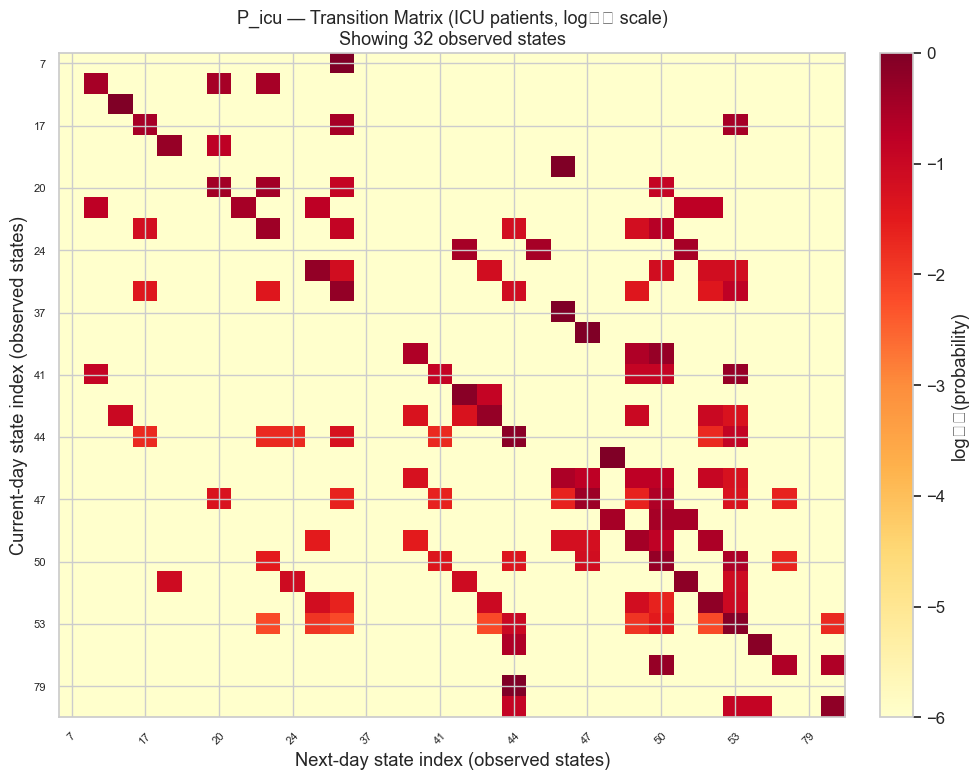

Figure saved: heatmap_P_icu.png


In [24]:
# ── Plot 1: P_icu heatmap (observed states only) ─────────────────────────────
obs = observed_states
P_icu_obs = P_icu[np.ix_(obs, obs)]

fig, ax = plt.subplots(figsize=(10, 8))
# Log-normalise; replace 0 with a very small number for display
data_log = np.log10(np.where(P_icu_obs > 0, P_icu_obs, 1e-6))
im = ax.imshow(data_log, aspect='auto', cmap='YlOrRd',
               vmin=-6, vmax=0)
ax.set_title('P_icu — Transition Matrix (ICU patients, log₁₀ scale)\n'
             f'Showing {len(obs)} observed states', fontsize=13)
ax.set_xlabel('Next-day state index (observed states)')
ax.set_ylabel('Current-day state index (observed states)')
# Annotate axis ticks with actual state numbers
tick_step = max(1, len(obs) // 10)
ax.set_xticks(range(0, len(obs), tick_step))
ax.set_xticklabels(obs[::tick_step], rotation=45, fontsize=8)
ax.set_yticks(range(0, len(obs), tick_step))
ax.set_yticklabels(obs[::tick_step], fontsize=8)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('log₁₀(probability)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'heatmap_P_icu.png'), dpi=120)
plt.show()
print('Figure saved: heatmap_P_icu.png')

**What we see (P_icu heatmap):** The diagonal is the brightest band — patients most commonly remain in the same state from one day to the next, reflecting the slow evolution of critical illness. Off-diagonal probability mass represents state changes. The sparse coverage is expected given only 100 patients; many states are never observed.

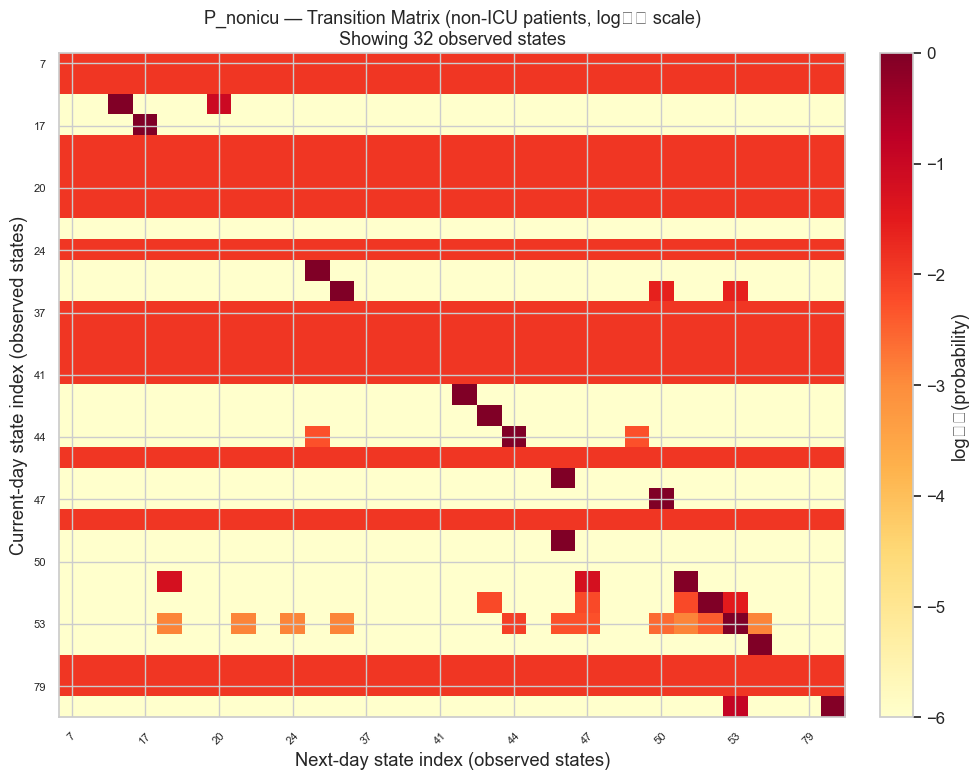

Figure saved: heatmap_P_nonicu.png


In [25]:
# ── Plot 2: P_nonicu heatmap ──────────────────────────────────────────────────
P_nonicu_obs = P_nonicu[np.ix_(obs, obs)]

fig, ax = plt.subplots(figsize=(10, 8))
data_log2 = np.log10(np.where(P_nonicu_obs > 0, P_nonicu_obs, 1e-6))
im2 = ax.imshow(data_log2, aspect='auto', cmap='YlOrRd',
                vmin=-6, vmax=0)
ax.set_title('P_nonicu — Transition Matrix (non-ICU patients, log₁₀ scale)\n'
             f'Showing {len(obs)} observed states', fontsize=13)
ax.set_xlabel('Next-day state index (observed states)')
ax.set_ylabel('Current-day state index (observed states)')
ax.set_xticks(range(0, len(obs), tick_step))
ax.set_xticklabels(obs[::tick_step], rotation=45, fontsize=8)
ax.set_yticks(range(0, len(obs), tick_step))
ax.set_yticklabels(obs[::tick_step], fontsize=8)
cb2 = fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
cb2.set_label('log₁₀(probability)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'heatmap_P_nonicu.png'), dpi=120)
plt.show()
print('Figure saved: heatmap_P_nonicu.png')

**What we see (P_nonicu heatmap):** Similar diagonal-dominant structure to P_icu. Non-ICU patients have generally fewer recorded transitions (the ward patients tend to be more stable), which can lead to sparser off-diagonal entries. Differences between the two heatmaps encode the clinical effect of ICU admission on patient dynamics.

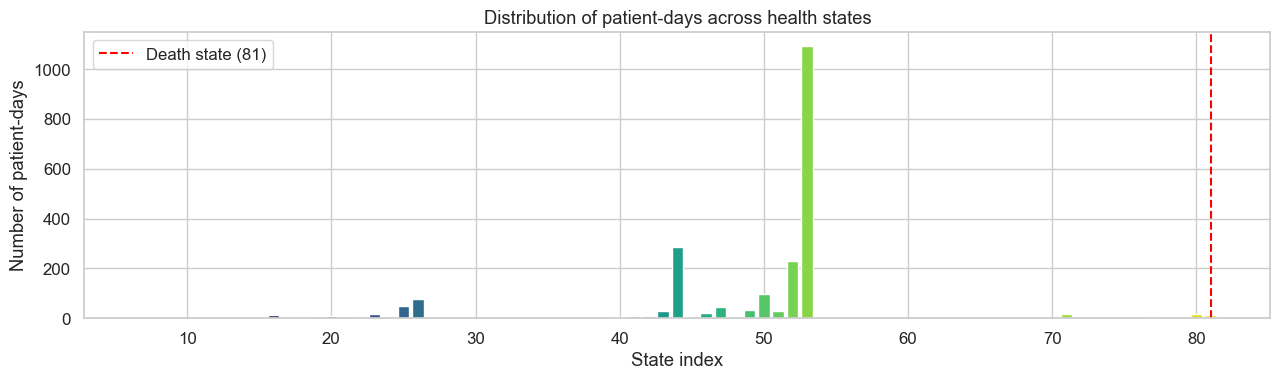

Figure saved: state_distribution.png


In [26]:
# ── Plot 3: state distribution (patient-days) ─────────────────────────────────
state_dist = features['state'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(state_dist.index, state_dist.values,
       color=sns.color_palette('viridis', len(state_dist)), width=0.8)
ax.axvline(DEATH_STATE, color='red', linestyle='--', linewidth=1.5,
           label=f'Death state ({DEATH_STATE})')
ax.set_xlabel('State index')
ax.set_ylabel('Number of patient-days')
ax.set_title('Distribution of patient-days across health states')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'state_distribution.png'), dpi=120)
plt.show()
print('Figure saved: state_distribution.png')

**What we see (state distribution):** The distribution is highly concentrated in a small number of states — most patient-days cluster in the healthier/normal-range states. This reflects the typical MIMIC-IV demo population: the majority of time is spent outside the critical window, with spikes at specific combinations of normal MAP + normal SpO2 + normal GCS + normal Lactate.

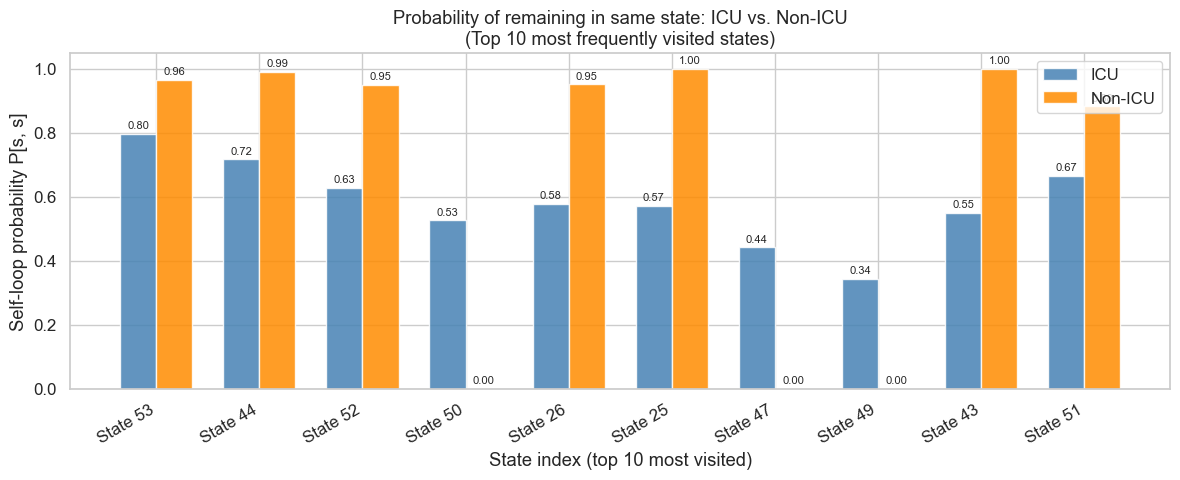

Figure saved: self_loop_comparison.png


In [27]:
# ── Plot 4: self-loop probability — ICU vs non-ICU ────────────────────────────
# For top-10 most visited states (excluding death), compare P[s,s] under each policy

top10_states = (
    features[features['state'] != DEATH_STATE]['state']
    .value_counts()
    .head(10)
    .index
    .tolist()
)

icu_self    = [P_icu[s, s]    for s in top10_states]
nonicu_self = [P_nonicu[s, s] for s in top10_states]

x = np.arange(len(top10_states))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, icu_self,    width, label='ICU',     color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, nonicu_self, width, label='Non-ICU', color='darkorange', alpha=0.85)

ax.set_xlabel('State index (top 10 most visited)')
ax.set_ylabel('Self-loop probability P[s, s]')
ax.set_title('Probability of remaining in same state: ICU vs. Non-ICU\n'
             '(Top 10 most frequently visited states)')
ax.set_xticks(x)
ax.set_xticklabels([f'State {s}' for s in top10_states], rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'self_loop_comparison.png'), dpi=120)
plt.show()
print('Figure saved: self_loop_comparison.png')

**What we see (self-loop comparison):** This is the most policy-relevant plot. For healthy states (high index), both ICU and non-ICU self-loops are high — stable patients stay stable. The interesting signal is in intermediate or lower states, where ICU care may either sustain or improve the patient's condition faster. With only 100 patients the estimates are noisy; this plot will become more informative with the full MIMIC-IV dataset.

---
## Section 9 — Summary & Caveats

We print a final numerical summary of the pipeline outputs.

In [28]:
# ── Final summary printout ───────────────────────────────────────────────────
n_patients     = features['subject_id'].nunique()
n_admissions   = features['hadm_id'].nunique()
n_icu_stays    = icustays['stay_id'].nunique()
n_total_trans  = len(transitions)
n_icu_trans    = int(transitions['is_icu'].sum())
n_nonicu_trans = n_total_trans - n_icu_trans
n_states_obs   = int((features['state'].value_counts() > 0).sum())
n_died         = int(features.loc[died_mask, 'subject_id'].nunique())

summary = {
    'Unique patients':                 n_patients,
    'Hospital admissions':             n_admissions,
    'ICU stays':                       n_icu_stays,
    'Total patient-days':              len(features),
    'Total transition pairs':          n_total_trans,
    '  ICU transitions':               n_icu_trans,
    '  Non-ICU transitions':           n_nonicu_trans,
    'Unique states observed':          n_states_obs,
    'State space size':                N_STATES,
    'Patients who died in hospital':   n_died,
}

print('=' * 50)
print('         PIPELINE SUMMARY')
print('=' * 50)
for k, v in summary.items():
    print(f'  {k:<38} {v:>6}')
print('=' * 50)

print('\nOutput files:')
print(f'  P_icu.npy    : {P_icu.shape}  row-stochastic')
print(f'  P_nonicu.npy : {P_nonicu.shape}  row-stochastic')

         PIPELINE SUMMARY
  Unique patients                           100
  Hospital admissions                       275
  ICU stays                                 140
  Total patient-days                       2149
  Total transition pairs                   1874
    ICU transitions                         604
    Non-ICU transitions                    1270
  Unique states observed                     33
  State space size                           82
  Patients who died in hospital              15

Output files:
  P_icu.npy    : (82, 82)  row-stochastic
  P_nonicu.npy : (82, 82)  row-stochastic


---
## Caveats & Limitations

1. **Small sample (N = 100 patients).** The MIMIC-IV *demo* dataset contains only 100 de-identified patients. Many of the 82 possible states are unobserved or observed only once, making the transition probability estimates highly uncertain. The full MIMIC-IV dataset (~50,000 ICU stays) is needed for reliable estimates.

2. **State space sparsity.** With $3^4 = 81$ live states and ~1,600 total transition pairs, most state-action pairs have zero or near-zero observed transitions. Rows with no observations are set to a uniform distribution — a crude fallback that understates uncertainty.

3. **Imputation assumptions.** GCS is not charted on non-ICU ward days; MAP and SpO2 coverage outside the ICU is also thin. Forward-filling and median imputation introduce bias — real deployment should use more principled methods (e.g., Gaussian process interpolation or MICE).

4. **ICU stay model simplification.** The pipeline labels a day as `is_icu = 1` based on calendar-day overlap with an ICU stay. In practice patients move in and out of ICU multiple times within an admission; the 7-day fixed-stay RMAB model is a further simplification.

5. **Death state.** We assign `state = 81` only to the *last* day of a fatal admission. Pre-death deterioration is not explicitly modelled — states in the days leading up to death use the same bins as non-fatal patients.

6. **No fairness split yet.** Section 6–7 use all available features. The fairness comparison (Model A with insurance/race vs. Model B health-only) is a downstream analysis step that re-runs this pipeline with feature subsets.

This notebook is a **prototype pipeline** demonstrating the end-to-end data flow. Results should be interpreted as methodological proof-of-concept, not clinical guidance.